# Epidemiological Model Assignment — Parameter Exploration

**Course**: KEN3170 — Multi-scale modeling of biological systems
**Group number**: 12

Assignment 1: how recovery rate affects epidemic outcomes in a SIRD, and comparasions


## Setup & Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

# Global plotting style so all figures in the notebook look consistent
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


In [3]:
def sird_model(y, t, beta, gamma, mu, N):
    """
    RHS of the SIRD ODE system.

    State (y): [S, I, R, D]
        S : Susceptible individuals
        I : Infectious individuals
        R : Recovered individuals
        D : Deceased individuals

    Parameters
    y: list or array
        Current state [S, I, R, D].
    t:
        Current time (required by odeint's signature, unused directly
        because the model has no explicit time dependence).
    beta:
        Transmission rate.
    gamma:
        Recovery rate.
    mu:
        Mortality rate.
    N:
        Total population size.

    Returns
    list
        Derivatives [dS/dt, dI/dt, dR/dt, dD/dt].
    """
    S, I, R, D = y

    #product of susceptible and infectious individuals, normalised by N.
    dSdt = -beta * S * I / N

    #Infectious individuals either recover (gamma) or die (mu).
    dIdt = beta * S * I / N - gamma * I - mu * I

    #Recovered compartment only grows, at rate gamma * I.
    dRdt = gamma * I

    #Deceased compartment only grows, at rate mu * I.
    dDdt = mu * I

    return [dSdt, dIdt, dRdt, dDdt]


### 1.1 Reasoning behind `sird_model` choices

- (`beta * S * I / N`): The new infection term
  assumes individuals mix, any susceptible person is equally
  likely to contact any infectious person, so the number of new infections scales with S and I.
  Dividing by `N` keeps the per-contact transmission
  probability, regardless of population size, for example: a city of 10000
  and a city of 10000000 with the same beta have comparable individual
  infection risk, rather than the larger city's contact count,
  making them a bigger epidemic.
- Why are gamma and mu both linear outflows from I?:
  Recovery and death as gamma*I and mu*I assumes each infectious
  individual has a constant daily probability of moving out of the
  infectious class, rather than everyone recovering after a fixed number of days.
  This is convenient and is the standard first approximation in real world epidemiology, even though real infectious
  periods are usually more tightly clustered around a mean than a distribution would predict.
- Why use a deterministic ODE rather than a stochastic simulation: For population sizes in the hundreds-to-thousands range used here, a
  deterministic ODE gives a clean, reproducible curve that isolates the
  effect of changing gamma without noise obscuring the comparison,
  even though real outbreaks have bigger variation that a deterministic model doesn't capture.


## 1.Parameter analysis

For each candidate recovery rate gamma in [0.05, 0.1, 0.15, 0.2, 0.25],
the function integrates the SIRD ODE system over the requested time using
scipy.integrate.odeint function, then extracts the epidemic curve's peak infectious count,
the day that peak occurs, the cumulative deaths at the end of the simulation, and the
basic reproduction number R0 = beta / gamma. All five runs are added up in a single dataFrame and plotted together.


In [4]:
def analyze_recovery_rates(beta, mu, N, I0, simulation_days,
                            gamma_values=(0.05, 0.1, 0.15, 0.2, 0.25),
                            plot=True):
    """
    Analyze epidemic outcomes for different recovery rates.

    For each value of gamma, this function:
      1. Solves the SIRD ODE system with scipy.integrate.odeint.
      2. Records the peak number of infectious individuals and the day it
         occurs.
      3. Records the cumulative number of deaths at the end of the
         simulation window.
      4. Computes the basic reproduction number R0 = beta / gamma.
    It then assembles the results into a tidy DataFrame and can
    draw a good quality figure comparing the infectious curves for
    every gamma value.

    Parameters
    beta:
        Transmission rate.
    mu:
        Mortality rate.
    N:
        Total population.
    I0:
        Initial infected individuals.
    simulation_days:
        Simulation duration in days.
    gamma_values:
        Recovery rates to test. Defaults to the five values required by
        the assignment (0.05 - 0.25).
    plot: bool, optional
        To draw the comparison figure set to true. Set to false if you only need the summary table, e.g. inside a loop.

    Returns
    pandas.DataFrame
        Results summary for each recovery rate, with columns
        ['gamma', 'R0', 'peak_infected', 'peak_day', 'total_deaths'].
    """
    #time grid: one point per day, inclusive of day 0.
    t = np.linspace(0, simulation_days, simulation_days + 1)

    #everyone who is not initially infected starts susceptible
    S0 = N - I0
    y0 = [S0, I0, 0, 0]

    records = []       #will hold one summary per gamma
    curves = {}         #gamma infectious curve

    for gamma in gamma_values:
        #integrate the SIRD system for this recovery rate.
        solution = odeint(sird_model, y0, t, args=(beta, gamma, mu, N))
        S, I, R, D = solution.T

        peak_infected = I.max()
        peak_day = t[np.argmax(I)]
        total_deaths = D[-1]
        R0 = beta / gamma

        records.append({
            "gamma": gamma,
            "R0": R0,
            "peak_infected": peak_infected,
            "peak_day": peak_day,
            "total_deaths": total_deaths,
        })
        curves[gamma] = I

    results_df = pd.DataFrame.from_records(records)
    # Round for readable display while keeping the underlying figures precise.
    results_df = results_df.round({"R0": 2, "peak_infected": 1,
                                    "peak_day": 1, "total_deaths": 1})

    if plot:
        fig, ax = plt.subplots(figsize=(9, 5.5))
        palette = sns.color_palette("viridis", n_colors=len(gamma_values))

        for color, gamma in zip(palette, gamma_values):
            ax.plot(t, curves[gamma], color=color, linewidth=2.2,
                    label=f"γ = {gamma}  (R0 = {beta/gamma:.2f})")

        ax.set_xlabel("Day")
        ax.set_ylabel("Infectious individuals")
        ax.set_title(f"Effect of recovery rate γ on the epidemic curve\n"
                     f"(β = {beta}, μ = {mu}, N = {N}, I0 = {I0})")
        ax.legend(title="Recovery rate", frameon=True)
        ax.set_xlim(0, simulation_days)
        ax.set_ylim(bottom=0)
        fig.tight_layout()
        plt.show()

    return results_df


### 2.1 Implementation decisions behind `analyze_recovery_rates`

- `scipy.integrate.odeint`\*\*: `odeint` uses an adaptive-step solver
  (LSODA under the hood) that handles the stiffness and
  control needed for smooth SIRD trajectories, making the model
  not need an Euler/Runge-Kutta integrator.
- (`np.linspace(0, simulation_days, simulation_days+1)`):
  One point per day gives the trajectories of (odeint
  take finer steps between the requested output
  points) while keeping the returned arrays at a better resolution
  (`peak_day` as a whole number of
  days, deaths "at end of simulation"). A coarser grid would risk missing
  the true peak; a much finer one would just add unnecessary array size
  without changing the reported metrics.
- Why `peak_infected`/`peak_day` are read directly off the discretized
  curve (`I.max()`, `t[np.argmax(I)]`) rather than solved analytically:
  the SIRD system has no closed-form solution for the infectious peak, so
  the standard approach would be to simulate the trajectory whole and take the
  maximum accurate to the resolution of the time grid.
- `total_deaths` is read as `D[-1]` rather than integrating `mu*I`
  separately: Since `D` is already an explicit compartment that only
  accumulates, it's value at the final simulated day is the
  total death count by construction no integration is
  needed.
- Why results are rounded for display but not for the underlying
  arrays?: `results_df` is rounded (`.round(...)`) for readability
  in the printed table and the curves used for plotting keep full
  floating-point precision, so the figures aren't affected by the rounding.


### 2.2 Example run of `analyze_recovery_rates`


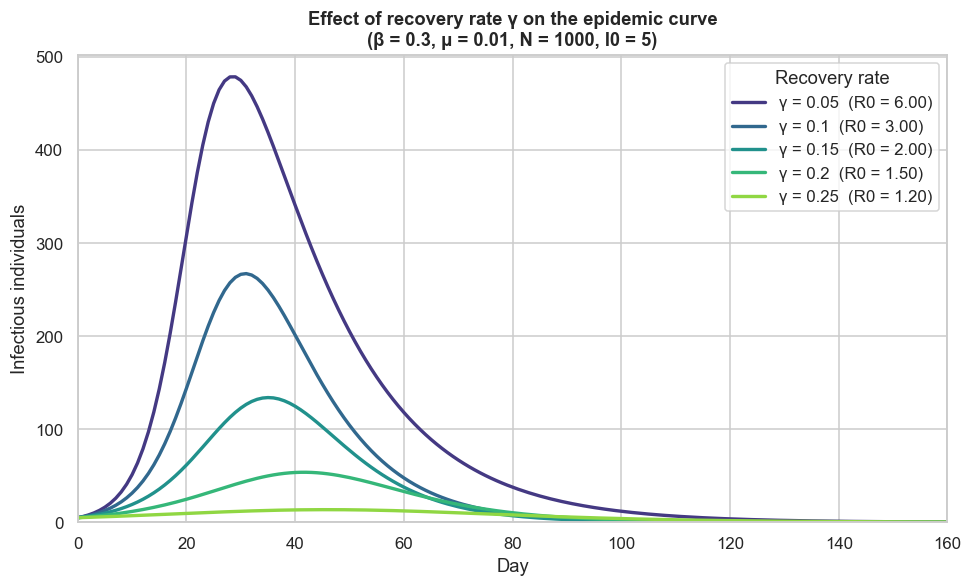

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,6.0,478.6,29.0,165.4
1,0.10,3.0,267.3,31.0,83.5
2,0.15,2.0,134.1,35.0,47.6
3,0.20,1.5,53.8,42.0,25.7
4,0.25,1.2,13.7,46.0,10.6


In [5]:
#example run with baseline parameters, testing purposes, before final comparasion
example_results = analyze_recovery_rates(
    beta=0.3, mu=0.01, N=1000, I0=5, simulation_days=160
)
example_results


## 2. Part 2 — Scenario comparison

**Scenario A — High Transmission**: `beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200`

**Scenario B — Low Transmission**: `beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200`

Both scenarios are run through `analyze_recovery_rates` across the same five recovery
rates, giving a comparison of how transmission and mortality rates
change the epidemic.


Scenario A — High Transmission


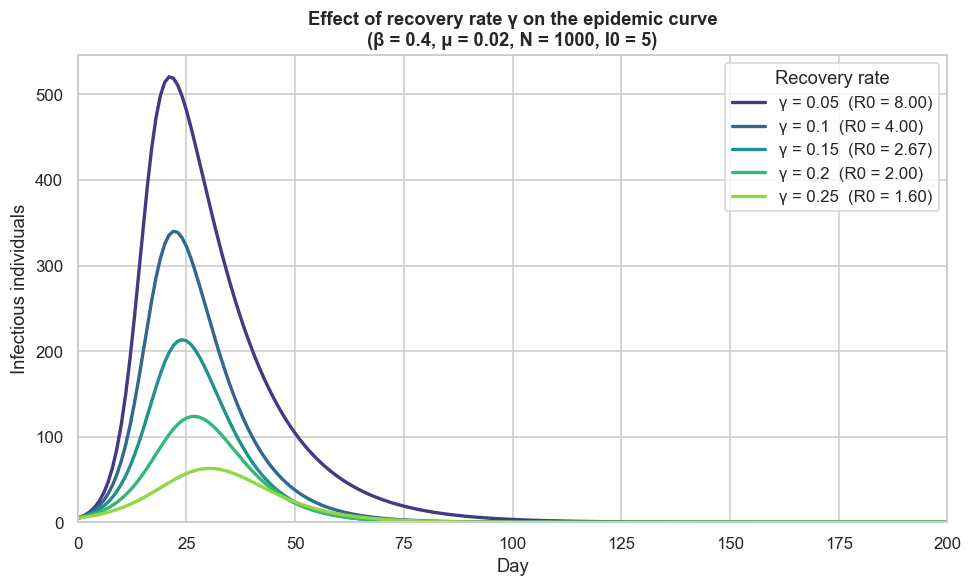

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,8.00,520.6,21.0,284.8
1,0.10,4.00,340.1,22.0,159.9
2,0.15,2.67,213.5,24.0,102.6
3,0.20,2.00,123.9,27.0,67.4
4,0.25,1.60,63.1,30.0,42.7


In [6]:
#High Transmission
scenario_A_params = dict(beta=0.4, mu=0.02, N=1000, I0=5, simulation_days=200)
print("Scenario A — High Transmission")
results_A = analyze_recovery_rates(**scenario_A_params)
results_A


Scenario B — Low Transmission


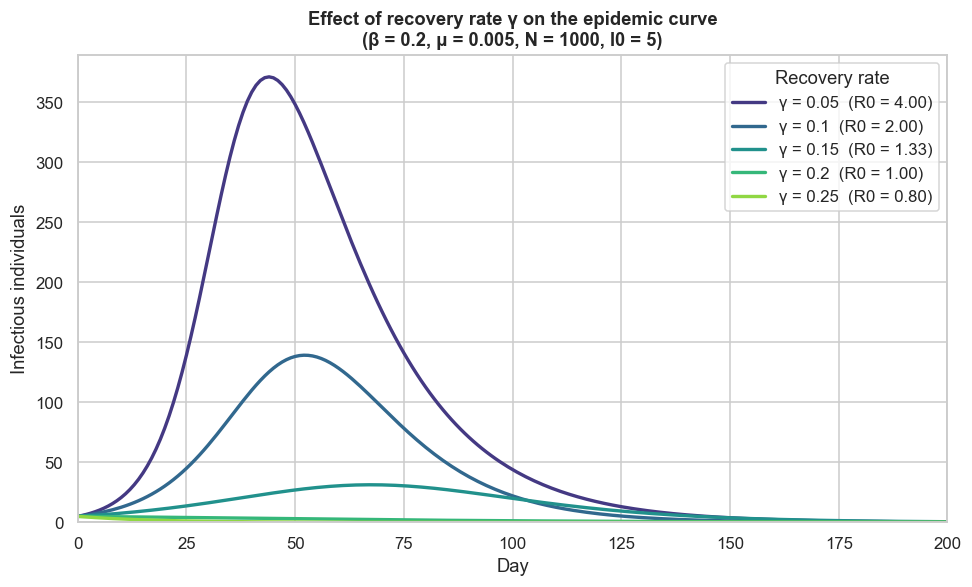

,gamma,R0,peak_infected,peak_day,total_deaths
0,0.05,4.00,371.4,44.0,88.2
1,0.10,2.00,139.3,52.0,36.7
2,0.15,1.33,31.3,67.0,13.6
3,0.20,1.00,5.0,0.0,1.8
4,0.25,0.80,5.0,0.0,0.4


In [7]:
#Low Transmission
scenario_B_params = dict(beta=0.2, mu=0.005, N=1000, I0=5, simulation_days=200)
print("Scenario B — Low Transmission")
results_B = analyze_recovery_rates(**scenario_B_params)
results_B


### 3.1 Side-by-side comparison table


In [8]:
# Combine both result tables into one frame, tagged by scenario, for an
# easy side-by-side read.
comparison_df = pd.concat(
    [results_A.assign(scenario="A - High Transmission"),
     results_B.assign(scenario="B - Low Transmission")],
    ignore_index=True
)[["scenario", "gamma", "R0", "peak_infected", "peak_day", "total_deaths"]]

comparison_df


,scenario,gamma,R0,peak_infected,peak_day,total_deaths
0,A - High Transmission,0.05,8.00,520.6,21.0,284.8
1,A - High Transmission,0.10,4.00,340.1,22.0,159.9
2,A - High Transmission,0.15,2.67,213.5,24.0,102.6
3,A - High Transmission,0.20,2.00,123.9,27.0,67.4
4,A - High Transmission,0.25,1.60,63.1,30.0,42.7
5,B - Low Transmission,0.05,4.00,371.4,44.0,88.2
6,B - Low Transmission,0.10,2.00,139.3,52.0,36.7
7,B - Low Transmission,0.15,1.33,31.3,67.0,13.6
8,B - Low Transmission,0.20,1.00,5.0,0.0,1.8
9,B - Low Transmission,0.25,0.80,5.0,0.0,0.4


### 3.2 Comparative visualization


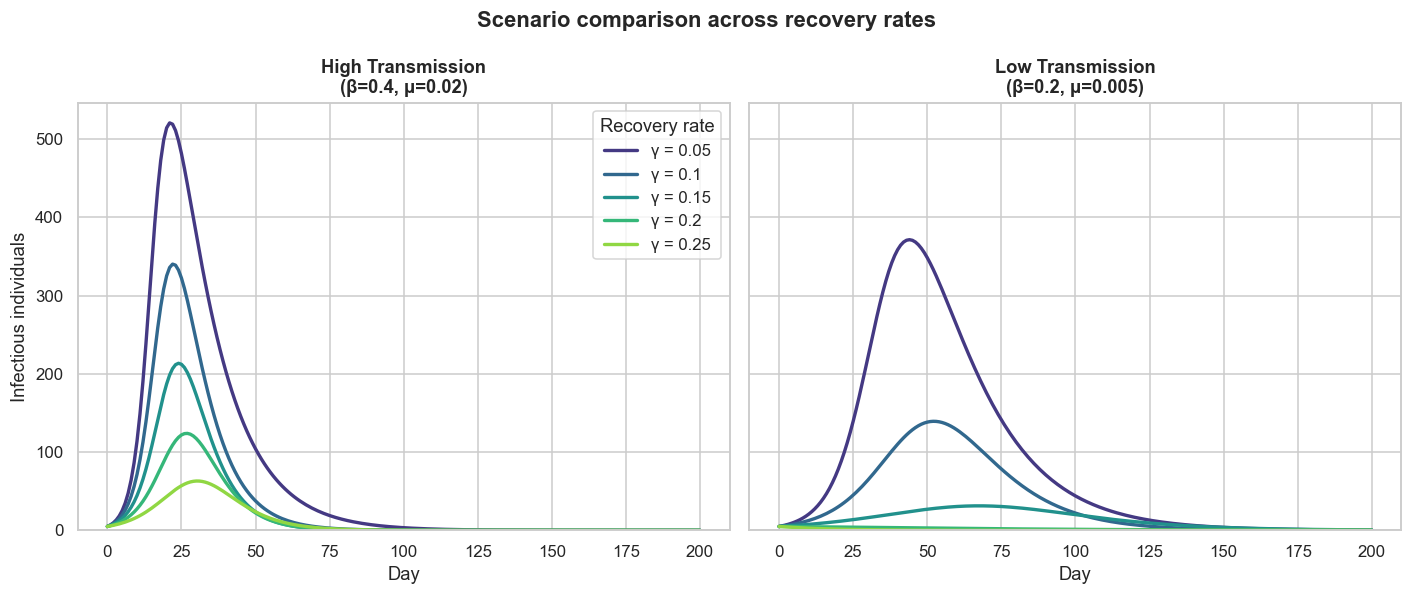

In [9]:
def plot_scenario_curves(params, gamma_values=(0.05, 0.1, 0.15, 0.2, 0.25)):
    """
    Re-solve the SIRD system for a single scenario across gamma_values and
    return the time grid plus a dict of {gamma: infectious_curve}.

    This mirrors the internal computation of analyze_recovery_rates but
    skips the DataFrame/plotting step, so the two scenarios' infectious
    curves can be drawn together on shared axes for direct comparison.
    """
    beta, mu, N, I0, simulation_days = (
        params["beta"], params["mu"], params["N"],
        params["I0"], params["simulation_days"]
    )
    t = np.linspace(0, simulation_days, simulation_days + 1)
    S0 = N - I0
    y0 = [S0, I0, 0, 0]

    curves = {}
    for gamma in gamma_values:
        solution = odeint(sird_model, y0, t, args=(beta, gamma, mu, N))
        curves[gamma] = solution[:, 1]  # infectious column
    return t, curves


t_A, curves_A = plot_scenario_curves(scenario_A_params)
t_B, curves_B = plot_scenario_curves(scenario_B_params)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
palette = sns.color_palette("viridis", n_colors=5)
gamma_values = (0.05, 0.1, 0.15, 0.2, 0.25)

for color, gamma in zip(palette, gamma_values):
    axes[0].plot(t_A, curves_A[gamma], color=color, linewidth=2.2,
                 label=f"γ = {gamma}")
    axes[1].plot(t_B, curves_B[gamma], color=color, linewidth=2.2,
                 label=f"γ = {gamma}")

axes[0].set_title("High Transmission\n(β=0.4, μ=0.02)")
axes[1].set_title("Low Transmission\n(β=0.2, μ=0.005)")
for ax in axes:
    ax.set_xlabel("Day")
    ax.set_ylim(bottom=0)
axes[0].set_ylabel("Infectious individuals")
axes[0].legend(title="Recovery rate", frameon=True)
fig.suptitle("Scenario comparison across recovery rates", fontweight="bold")
fig.tight_layout()
plt.show()


### 3.3 Which scenario is worse for public health, and why?

Scenario A (High Transmission) is worse for public health across every recovery rate
tested. Its higher transmission rate (`beta = 0.4` vs `0.2`) roughly doubles the basic
reproduction number `R0` for any given gamma, which produces a taller, earlier
infectious peak — more people are sick at the same time, straining healthcare capacity
sooner. Scenario A's mortality rate (`mu = 0.02`) is also four times higher than
Scenario B's (`mu = 0.005`), so a larger fraction of every infectious "cohort" dies
rather than recovers. The combination of a bigger peak and a higher per-infection death
probability means Scenario A's cumulative death toll is substantially larger than
Scenario B's at every recovery rate in the table above. Scenario B's lower transmission
rate keeps R0 closer to (or below, for higher gamma) the epidemic threshold, and its
much lower mortality rate means even the infections that do occur are far less likely
to be fatal. In short: Scenario A stresses the health system harder (higher, earlier
peak) and directly kills more people per infection (higher mu), so it dominates
Scenario B on both epidemic size and severity.


## 3. Part 3 — Policy recommendations


### 3.1 Parameter impact analysis

How does increasing recovery rate affect peak infections, total deaths, and epidemic duration?
Use specific numbers from your results to support your conclusions


In [10]:
#how long does the epidemic last for each gamma?
#we count the epidemic as over on the first day after the peak where less than 1 person is infectious
def epidemic_duration(params, gamma_values=(0.05, 0.1, 0.15, 0.2, 0.25)):
    t, curves = plot_scenario_curves(params, gamma_values)
    rows = []
    for gamma in gamma_values:
        I = curves[gamma]
        peak_day = np.argmax(I)
        #days after the peak where I drops below 1
        over = np.where((I < 1) & (t > peak_day))[0]
        duration = t[over[0]] if len(over) > 0 else np.nan  #nan if it never ends in the simulation
        rows.append({"gamma": gamma, "peak_day": t[peak_day], "duration_days": duration})
    return pd.DataFrame(rows)

duration_A = epidemic_duration(scenario_A_params)
duration_B = epidemic_duration(scenario_B_params)

print("High Transmission")
print(duration_A.to_string(index=False))
print()
print("Low Transmission")
print(duration_B.to_string(index=False))


High Transmission
 gamma  peak_day  duration_days
  0.05      21.0          118.0
  0.10      22.0           86.0
  0.15      24.0           77.0
  0.20      27.0           78.0
  0.25      30.0           84.0

Low Transmission
 gamma  peak_day  duration_days
  0.05      44.0          178.0
  0.10      52.0          154.0
  0.15      67.0          185.0
  0.20       0.0          116.0
  0.25       0.0           28.0


Increasing the recovery rate (gamma) causes all the outcomes we measured to improve as it shortens the average period someone is infectious and this causes R0 to decrease. Each person that is infectious has less time to pass the disease to the next and also less time in which they die.

This conclusion is supported by the following:

__Peak infections__: Increasing gamma causes a lower and later peak, in scenario A when we increased gamma from 0.05 to 0.25 results in a decrease in the peak from 520 people down to 63 infectious people. Along with this the peak day moves a bit later to day 30 from day 21 originally. IN the second scenario when the gamma is increased to values 0.15, 0.2 and 0.25, it causes the peak to drop from orignally 371 to 31.3 (gamma = 0.15) and for the other two values the infectious count never goes above the inital 5 cases. This is as the effective reporduction number is already below one and the outbreak disappears from day 0.

__Total Death__: When gamma is increased deaths fall largely, the main reason for this being fewer people are infected overall and each infected person is infectious for a lesser period of time (where they could die aswell). In the first scenario, total deaths change as the follows:

Gamma 0.05: Total Deaths 284.4 <br>
Gamma 0.10: Total Deaths 159.9 <br>
Gamma 0.15: Total Deaths 102.6 <br>
Gamma 0.20: Total Deaths 67.4 <br>
Gamma 0.25: Total Deaths 42.7 <br>

As you can see increasing gamma 2x almost halves deaths. For scenario B the results are similar as it drops from 88.2 to 0.4 within the same range as scenario A. Even the susceptible count changes, in scenario A it goes from 99.7% down to 57.6%


__Epidemic Duration__: For duration we counted the epidemic as finished on the first day after the peak where less than 1 person is still infectious (see the table above). Unlike the peak and the deaths, increasing gamma does not always make the epidemic shorter. It gets shorter in the begining but then increases a bit at 0.15 because with a high R0 almost everyone gets infected really quickly and then theres no one left to infect so it ends quick but as you can see when R0 gets closer to 1 the outbreak becomes a lot smaller and spreads slower so it goes on for longer. You can notice the same in scenario b at gamma 0.15 the peak is only 31 people but it goes on for 185 days which is longer than what it was at gamma 0.05 (178 days peak 371). 

Overall increasing the gamma lowers how many people are sick at once and die but it only makes the epidemic shorter once R0 goes below 1.

### 3.2 Intervention analysis

If an intervention could increase recovery rate by 50%, what would be the expected impact on total deaths?
Use Scenario A as your baseline and show calculations


From the data from scenario A, the number of deaths decreases in mostly linear manner, but if we plot we that data can see that we have a


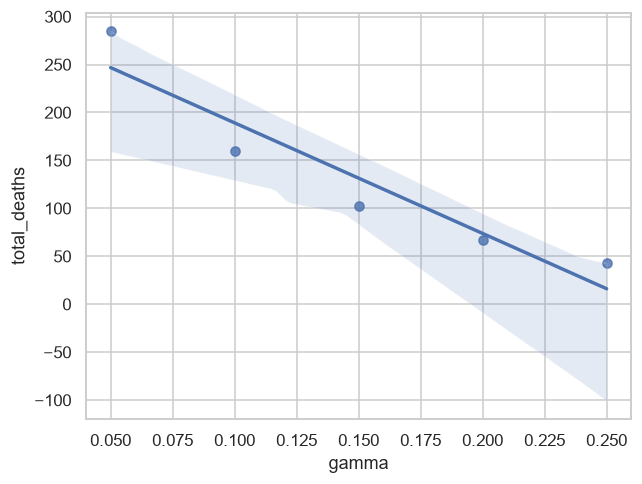

In [ ]:
sns.regplot(x='gamma', y='total_deaths', data = results_A);
plt.show()

### 3.3 Real-world application

Name one real medical intervention that could increase recovery rates
Explain the mechanism and estimate realistic effectiveness


Conclusions

- The recovery rate (gamma) is a powerful lever on epidemic severity: across the tested
  range (0.05–0.25), higher gamma consistently produced smaller, earlier, less deadly
  outbreaks, driven by its direct, inverse relationship with `R0 = beta / gamma`.
- Scenario A (High Transmission: beta=0.4, mu=0.02) was worse than Scenario B (Low
  Transmission: beta=0.2, mu=0.005) at every recovery rate tested, driven both by a
  higher R0 (bigger, earlier peaks) and a higher mortality rate (more deaths per
  infection).
- Beta, gamma, and mu each map to distinct, real intervention families (transmission
  control, treatment/recovery speed, and care quality/capacity respectively), and
  effective epidemic policy typically combines interventions across more than one of
  these parameters rather than relying on a single lever.
- The `R0 = beta / gamma` threshold remains a simple, robust guide for evaluating
  whether a given policy package is sufficient to shrink an epidemic rather than merely
  slow it down.
